In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
RANDOM_STATE = 42

In [2]:
df = pd.read_csv('../data/wholesale_customers.csv')
print(df.shape)
df.describe()

(440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [4]:
from scipy.stats import skew

SPENDING_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

skewness = df[SPENDING_COLS].apply(lambda x: skew(x))
skewness.sort_values(ascending=False)

Delicassen          11.113534
Frozen               5.887826
Milk                 4.039922
Detergents_Paper     3.619458
Grocery              3.575187
Fresh                2.552583
dtype: float64

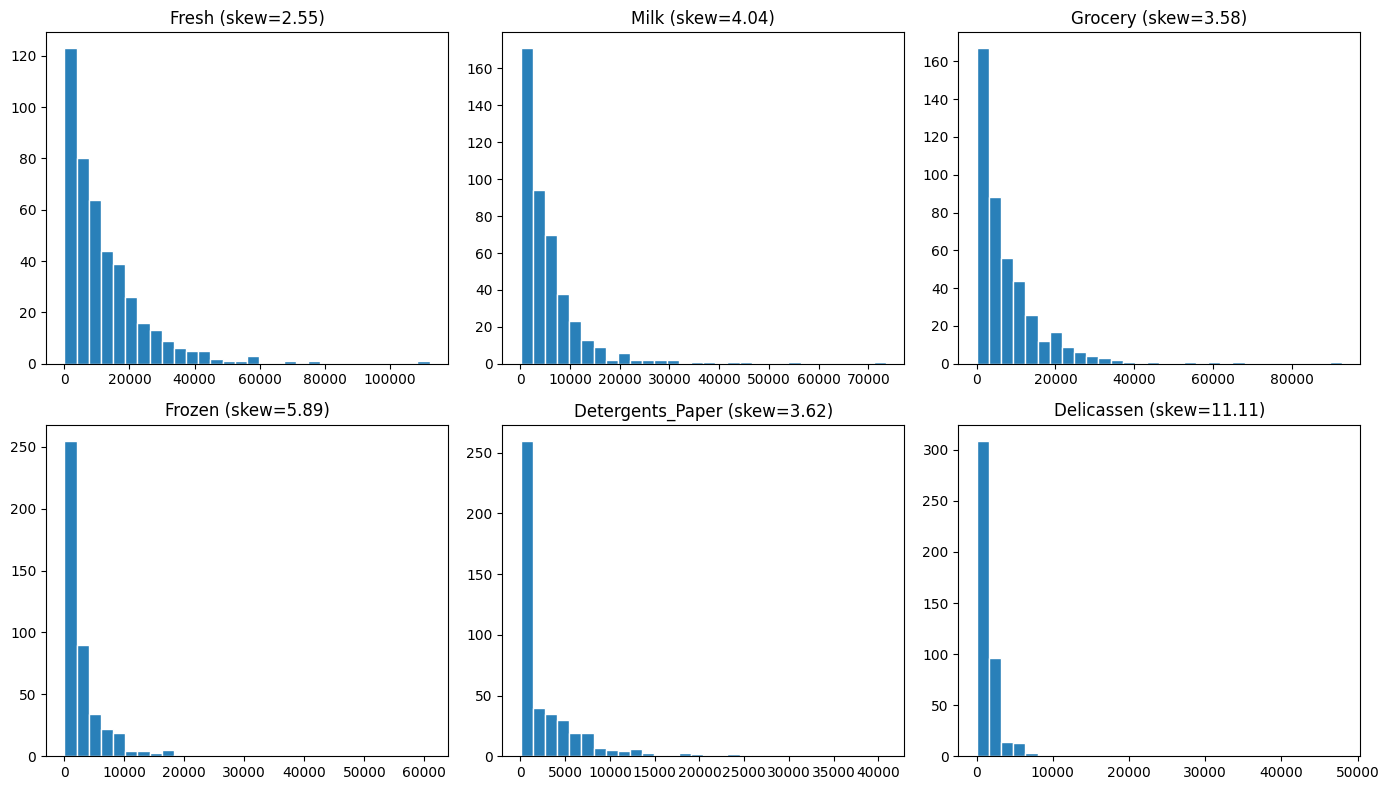

In [5]:
import os
os.makedirs('../assets', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(SPENDING_COLS):
    axes[i].hist(df[col], bins=30, color='#2980b9', edgecolor='white')
    axes[i].set_title(f'{col} (skew={skewness[col]:.2f})')
plt.tight_layout()
plt.savefig('../assets/01_raw_distributions_skew.png')
plt.show()

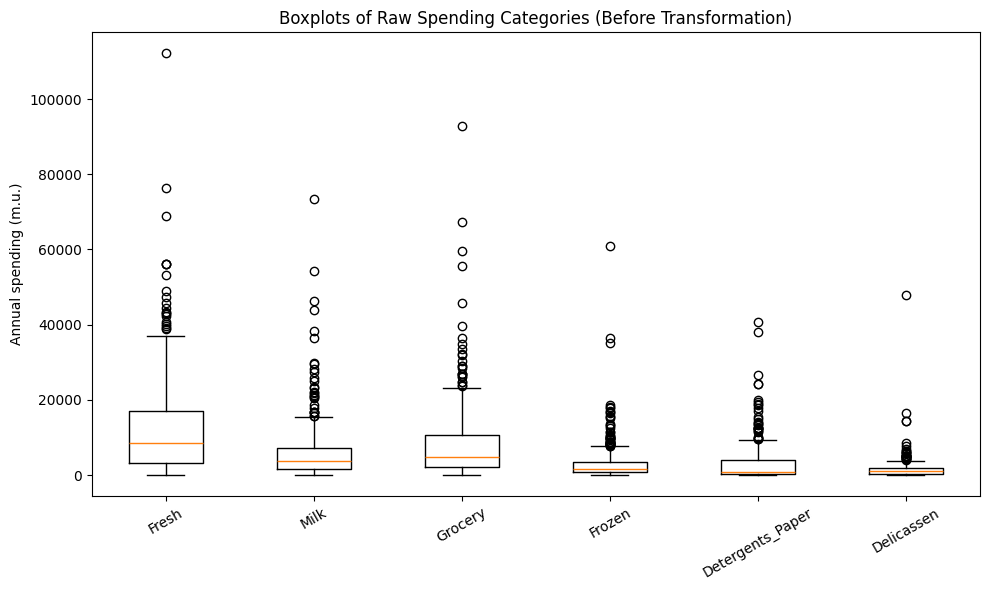

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([df[col] for col in SPENDING_COLS], tick_labels=SPENDING_COLS)
ax.set_title('Boxplots of Raw Spending Categories (Before Transformation)')
ax.set_ylabel('Annual spending (m.u.)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../assets/02_raw_boxplots_outliers.png')
plt.show()

In [7]:
CLUSTER_FEATURES = SPENDING_COLS  # Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen
VALIDATION_FEATURES = ['Channel', 'Region']

print("Features used for clustering:", CLUSTER_FEATURES)
print("Features held out for validation:", VALIDATION_FEATURES)

# Quick look at how Channel/Region relate to raw spending, just for context
df.groupby('Channel')[SPENDING_COLS].mean().round(1)

Features used for clustering: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Features held out for validation: ['Channel', 'Region']


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,,,,,,
1,13475.6,3451.7,3962.1,3748.3,790.6,1416.0
2,8904.3,10716.5,16322.9,1652.6,7269.5,1753.4


In [8]:
df_log = df.copy()
for col in SPENDING_COLS:
    df_log[col] = np.log1p(df_log[col])

skewness_after = df_log[SPENDING_COLS].apply(lambda x: skew(x))

comparison = pd.DataFrame({'Before (raw)': skewness, 'After (log1p)': skewness_after})
comparison.round(3)

,Before (raw),After (log1p)
Fresh,2.553,-1.570
Milk,4.040,-0.223
Grocery,3.575,-0.673
Frozen,5.888,-0.351
Detergents_Paper,3.619,-0.235
Delicassen,11.114,-1.088


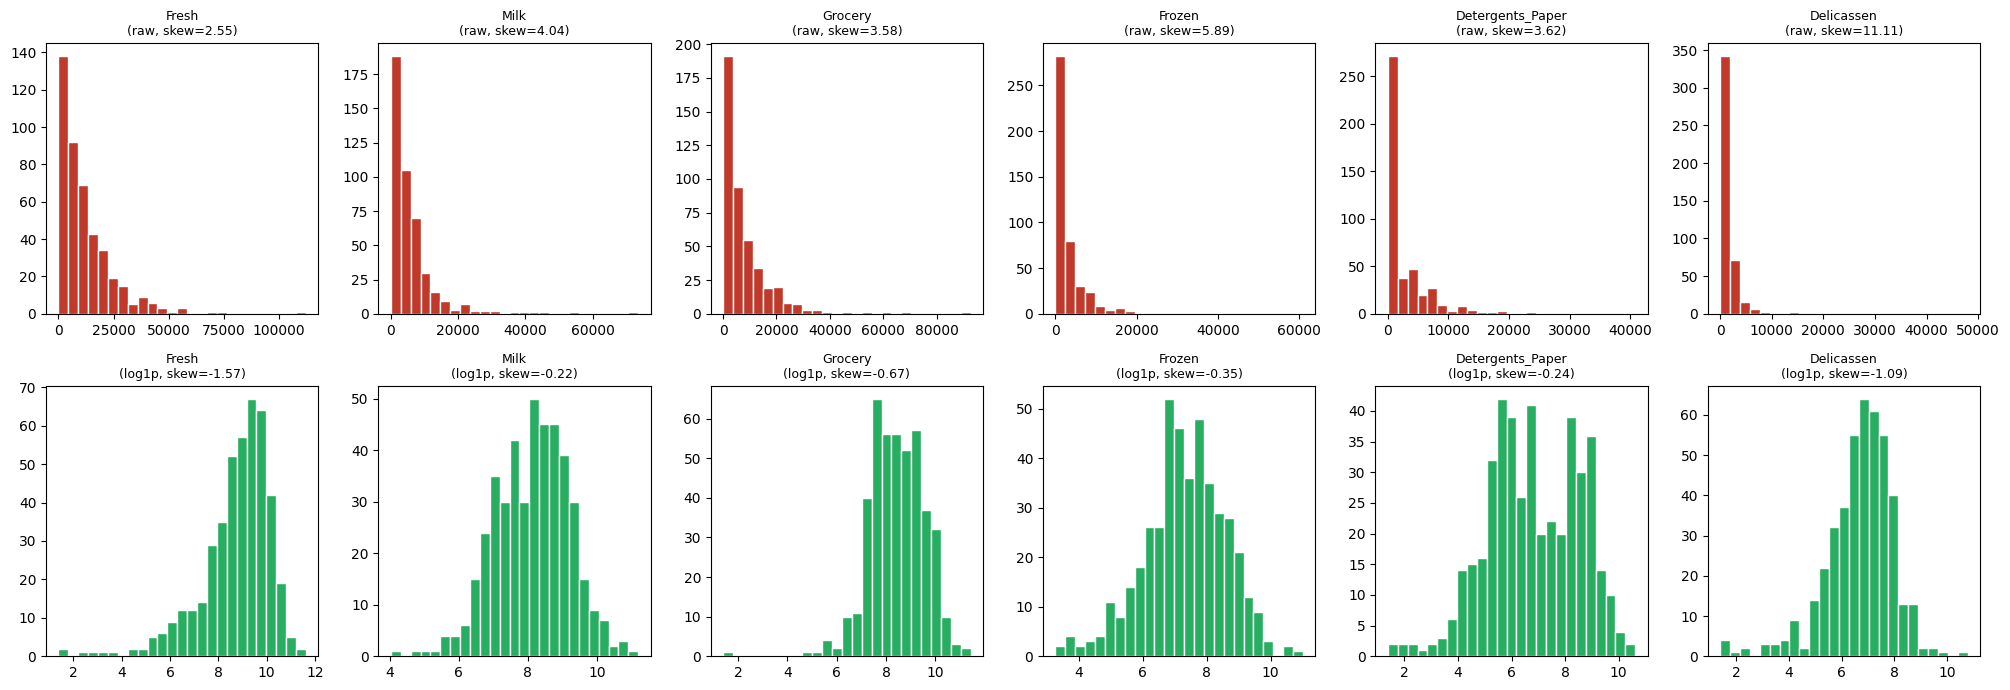

In [9]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, col in enumerate(SPENDING_COLS):
    axes[0, i].hist(df[col], bins=25, color='#c0392b', edgecolor='white')
    axes[0, i].set_title(f'{col}\n(raw, skew={skewness[col]:.2f})', fontsize=9)
    axes[1, i].hist(df_log[col], bins=25, color='#27ae60', edgecolor='white')
    axes[1, i].set_title(f'{col}\n(log1p, skew={skewness_after[col]:.2f})', fontsize=9)
plt.tight_layout()
plt.savefig('../assets/03_before_after_log_transform.png')
plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log[SPENDING_COLS])
X_scaled = pd.DataFrame(X_scaled, columns=SPENDING_COLS)

X_scaled.describe().round(2)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.00,-3.79,-6.36,-3.16,-3.17,-4.09
25%,-0.47,-0.73,-0.69,-0.54,-0.73,-0.51
50%,0.21,0.07,0.02,0.02,-0.05,0.16
75%,0.68,0.70,0.75,0.68,0.87,0.65
max,1.97,2.86,2.70,2.90,2.24,3.18
